# 02 — Preprocessing & Exploratory Data Analysis
**BanglaCyberBench: A Robust Multi-Source Benchmark and Transformer Ensemble for Cyberbullying Detection in Bengali**

This notebook performs:
1. Load the merged benchmark dataset from `01_data_collection_and_merge`
2. Exploratory Data Analysis (class distributions, text lengths, source breakdown)
3. Text preprocessing pipeline (Unicode normalization, emoji handling, URL/mention masking, Banglish normalization, repeated char reduction)
4. Save the cleaned dataset for downstream model training

**Prerequisites:** Run `01_data_collection_and_merge.ipynb` first so that the merged CSV exists.

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import os
import re
import sys
import warnings
import unicodedata
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.15)
rcParams["figure.dpi"] = 120
rcParams["figure.figsize"] = (10, 5)

# Try installing emoji library (optional but recommended)
try:
    import emoji
    print(f"emoji library: {emoji.__version__}")
except ImportError:
    print("⚠ emoji library not found. Install with: pip install emoji")
    print("  Falling back to regex-based emoji removal.")

print(f"Python  {sys.version}")
print(f"Pandas  {pd.__version__}")
print(f"NumPy   {np.__version__}")

⚠ emoji library not found. Install with: pip install emoji
  Falling back to regex-based emoji removal.
Python  3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]
Pandas  3.0.1
NumPy   2.4.3


## 1 — Load Merged Dataset

We load the benchmark dataset created in notebook 01. Expected columns:
- `text` — raw comment / post
- `label_binary` — 0 (not harmful) / 1 (harmful)
- `label_type` — abuse category (e.g., sexual, threat, religious, personal, troll, none)
- `label_severity` — severity level (none, mild, moderate, severe)
- `source` — originating dataset name
- `script` — writing script (bangla / romanized / mixed)

> **Note:** If your notebook 01 uses different column names, adjust the `COLUMN_MAP` in the cell below.

In [2]:
# ── Paths – point to the merged dataset created by notebook 01 ─────────────
MERGED_DATA_PATH = "../data/merged/benchmark_raw.csv"

if os.path.isfile(MERGED_DATA_PATH):
    df = pd.read_csv(MERGED_DATA_PATH)
    print(f"✅ Loaded merged dataset from: {MERGED_DATA_PATH}")
else:
    # Fallback: search for any merged CSV
    print(f"❌ Merged dataset not found at {MERGED_DATA_PATH}")
    print("Searching for alternative merged files...")
    found = False
    for search_dir in ["../data", "data", "."]:
        for root, dirs, files in os.walk(search_dir):
            for f in files:
                if "merged" in f.lower() and f.endswith(".csv"):
                    fpath = os.path.join(root, f)
                    print(f"  Found: {fpath}")
                    df = pd.read_csv(fpath)
                    found = True
                    break
            if found:
                break
        if found:
            break
    if not found:
        raise FileNotFoundError(
            "No merged dataset found. Please run the merging cell in notebook 01 first."
        )

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head(3)

✅ Loaded merged dataset from: ../data/merged/benchmark_raw.csv
Shape: (135575, 6)
Columns: ['text', 'label_binary', 'label_type', 'source', 'script', 'original_file']


,text,label_binary,label_type,source,script,original_file
0,Moja paici anek😁😁😂😂,0,none,banth,romanized,full_with_stats.csv
1,Haha ...ki likhe dilen 🤔 sorry?,0,none,banth,romanized,full_with_stats.csv
2,Muniyar piles operation kora dorkar😂😂,0,none,banth,romanized,full_with_stats.csv


### 1.1 — Column Standardization

If the column names from notebook 01 differ from the expected schema, map them here.

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# COLUMN MAPPING — EDIT THIS DICT IF YOUR COLUMN NAMES DIFFER
# ══════════════════════════════════════════════════════════════════════════════
COLUMN_MAP = {
    # "original_col_name": "standard_name",
    # e.g. "comment": "text",
    # e.g. "is_bully": "label_binary",
    # e.g. "category": "label_type",
    # e.g. "dataset_name": "source",
}

if COLUMN_MAP:
    df.rename(columns=COLUMN_MAP, inplace=True)
    print("Columns renamed.")

# ── Verify required columns exist ───────────────────────────────────────────
REQUIRED = ["text"]
OPTIONAL = ["label_binary", "label_type", "label_severity", "source", "script"]

for col in REQUIRED:
    assert col in df.columns, f"Missing required column: '{col}'. Available: {list(df.columns)}"

present_optional = [c for c in OPTIONAL if c in df.columns]
missing_optional = [c for c in OPTIONAL if c not in df.columns]

print(f"Required columns  : {REQUIRED}  ✅")
print(f"Optional (present): {present_optional}")
if missing_optional:
    print(f"Optional (missing): {missing_optional} — some analyses will be skipped")

print(f"\nAll columns: {list(df.columns)}")
print(f"\nDtypes:")
print(df.dtypes)

Required columns  : ['text']  ✅
Optional (present): ['label_binary', 'label_type', 'source', 'script']
Optional (missing): ['label_severity'] — some analyses will be skipped

All columns: ['text', 'label_binary', 'label_type', 'source', 'script', 'original_file']

Dtypes:
text               str
label_binary     int64
label_type         str
source             str
script             str
original_file      str
dtype: object


## 2 — Exploratory Data Analysis

### 2.1 — Basic Statistics

In [4]:
print(f"Total samples     : {len(df):,}")
print(f"Duplicate texts   : {df['text'].duplicated().sum():,}")
print(f"Null texts        : {df['text'].isna().sum():,}")

# Text length stats
df["_char_len"] = df["text"].astype(str).str.len()
df["_word_count"] = df["text"].astype(str).str.split().str.len()

print(f"\n── Text length (chars) ──")
print(df["_char_len"].describe().round(1))
print(f"\n── Word count ──")
print(df["_word_count"].describe().round(1))

Total samples     : 135,575
Duplicate texts   : 40,590
Null texts        : 0

── Text length (chars) ──
count    135575.0
mean         69.1
std          98.8
min           1.0
25%          23.0
50%          40.0
75%          75.0
max        1951.0
Name: _char_len, dtype: float64

── Word count ──
count    135575.0
mean         12.1
std          16.6
min           1.0
25%           4.0
50%           7.0
75%          13.0
max         368.0
Name: _word_count, dtype: float64


### 2.2 — Class Distribution (Binary)

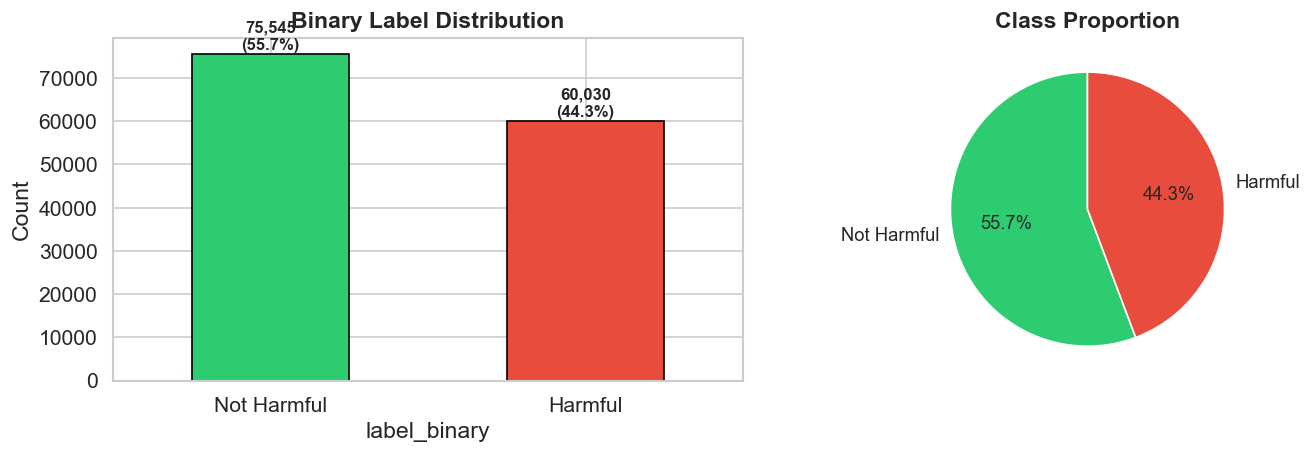

Imbalance ratio (majority/minority): 1.26:1


In [5]:
if "label_binary" in df.columns:
    os.makedirs("../outputs", exist_ok=True)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Count plot
    vc = df["label_binary"].value_counts().sort_index()
    label_names = {0: "Not Harmful", 1: "Harmful"}
    vc_named = vc.rename(index=label_names)
    vc_named.plot.bar(ax=axes[0], color=["#2ecc71", "#e74c3c"], edgecolor="black")
    axes[0].set_title("Binary Label Distribution", fontweight="bold")
    axes[0].set_ylabel("Count")
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
    for i, v in enumerate(vc_named.values):
        axes[0].text(i, v + len(df)*0.008, f"{v:,}\n({v/len(df)*100:.1f}%)",
                     ha="center", fontsize=10, fontweight="bold")

    # Pie chart
    vc_named.plot.pie(ax=axes[1], autopct="%1.1f%%", colors=["#2ecc71", "#e74c3c"],
                startangle=90, textprops={"fontsize": 11})
    axes[1].set_ylabel("")
    axes[1].set_title("Class Proportion", fontweight="bold")

    plt.tight_layout()
    plt.savefig("../outputs/fig_binary_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Imbalance ratio
    majority = vc.max()
    minority = vc.min()
    print(f"Imbalance ratio (majority/minority): {majority/minority:.2f}:1")
else:
    print("⚠ 'label_binary' column not found — skipping.")

### 2.3 — Abuse Type Distribution (Multi-class)

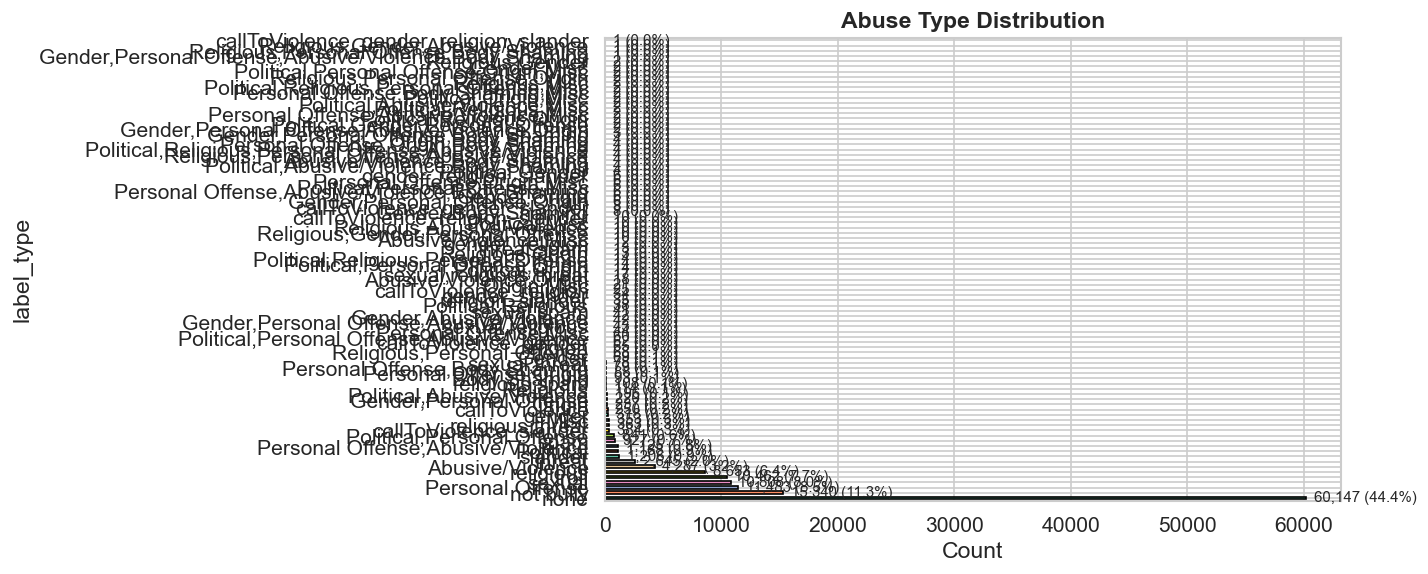


── Abuse type value counts ──
label_type
none                                                     60147
not bully                                                15340
Personal Offense                                         11483
sexual                                                   10808
troll                                                    10462
religious                                                 8653
Abusive/Violence                                          4287
threat                                                    2645
slander                                                   1206
Political                                                 1188
Personal Offense,Abusive/Violence                         1125
spam                                                       927
Political,Personal Offense                                 841
callToViolence_slander                                     384
religious,threat                                           363
Misc         

In [6]:
if "label_type" in df.columns:
    fig, ax = plt.subplots(figsize=(12, 5))
    vc = df["label_type"].value_counts()
    colors = sns.color_palette("Set2", len(vc))
    vc.plot.barh(ax=ax, color=colors, edgecolor="black")
    ax.set_title("Abuse Type Distribution", fontweight="bold")
    ax.set_xlabel("Count")
    for i, (v, name) in enumerate(zip(vc.values, vc.index)):
        ax.text(v + len(df)*0.005, i, f"{v:,} ({v/len(df)*100:.1f}%)",
                va="center", fontsize=9)
    plt.tight_layout()
    plt.savefig("../outputs/fig_abuse_type_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()
    
    print("\n── Abuse type value counts ──")
    print(df["label_type"].value_counts().to_string())
else:
    print("⚠ 'label_type' column not found — skipping.")

### 2.4 — Severity Distribution

In [7]:
if "label_severity" in df.columns:
    severity_order = ["none", "mild", "moderate", "severe"]
    vc = df["label_severity"].value_counts()
    # Reorder if possible
    ordered_idx = [s for s in severity_order if s in vc.index]
    remaining = [s for s in vc.index if s not in ordered_idx]
    vc = vc.reindex(ordered_idx + remaining)

    fig, ax = plt.subplots(figsize=(8, 4))
    sev_colors = {"none": "#2ecc71", "mild": "#f1c40f", "moderate": "#e67e22", "severe": "#e74c3c"}
    bar_colors = [sev_colors.get(str(s).lower(), "#95a5a6") for s in vc.index]
    vc.plot.bar(ax=ax, color=bar_colors, edgecolor="black")
    ax.set_title("Severity Distribution", fontweight="bold")
    ax.set_ylabel("Count")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    for i, v in enumerate(vc.values):
        ax.text(i, v + len(df)*0.008, f"{v:,}", ha="center", fontsize=10, fontweight="bold")
    plt.tight_layout()
    plt.savefig("../outputs/fig_severity_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("⚠ 'label_severity' column not found — skipping.")

⚠ 'label_severity' column not found — skipping.


### 2.5 — Source Breakdown

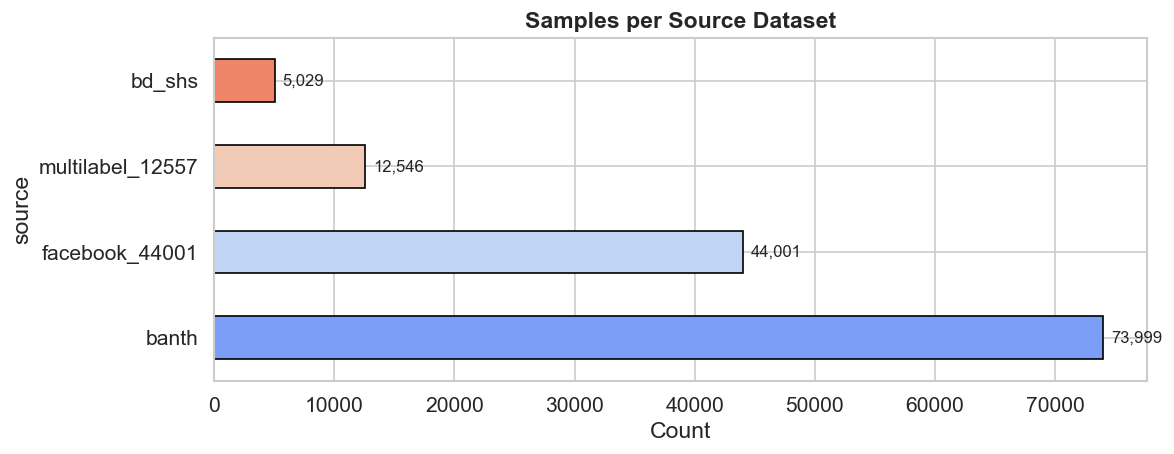


── Class balance per source ──
                  Not Harmful %  Harmful %
source                                    
banth                      71.8       28.2
bd_shs                     52.0       48.0
facebook_44001             34.9       65.1
multilabel_12557           35.8       64.2


In [8]:
if "source" in df.columns:
    fig, ax = plt.subplots(figsize=(10, max(4, len(df['source'].unique())*0.6)))
    vc = df["source"].value_counts()
    vc.plot.barh(ax=ax, color=sns.color_palette("coolwarm", len(vc)), edgecolor="black")
    ax.set_title("Samples per Source Dataset", fontweight="bold")
    ax.set_xlabel("Count")
    for i, v in enumerate(vc.values):
        ax.text(v + len(df)*0.005, i, f"{v:,}", va="center", fontsize=10)
    plt.tight_layout()
    plt.savefig("../outputs/fig_source_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()

    if "label_binary" in df.columns:
        ct = pd.crosstab(df["source"], df["label_binary"], normalize="index") * 100
        ct.columns = ["Not Harmful %", "Harmful %"]
        print("\n── Class balance per source ──")
        print(ct.round(1).to_string())
else:
    print("⚠ 'source' column not found — skipping.")

### 2.6 — Script Distribution (Bangla vs Romanized vs Mixed)

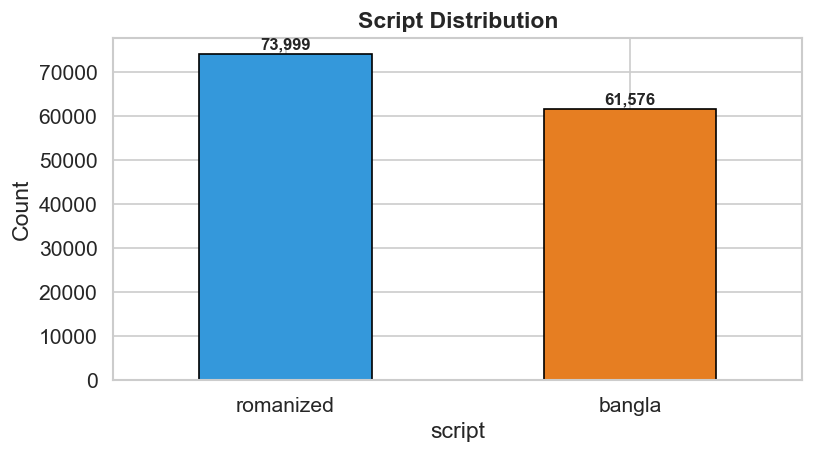

In [9]:
if "script" in df.columns:
    fig, ax = plt.subplots(figsize=(7, 4))
    vc = df["script"].value_counts()
    colors_s = ["#3498db", "#e67e22", "#95a5a6", "#9b59b6"][:len(vc)]
    vc.plot.bar(ax=ax, color=colors_s, edgecolor="black")
    ax.set_title("Script Distribution", fontweight="bold")
    ax.set_ylabel("Count")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    for i, v in enumerate(vc.values):
        ax.text(i, v + len(df)*0.008, f"{v:,}", ha="center", fontsize=10, fontweight="bold")
    plt.tight_layout()
    plt.savefig("../outputs/fig_script_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("⚠ 'script' column not found — skipping.")

### 2.7 — Text Length Distributions by Class

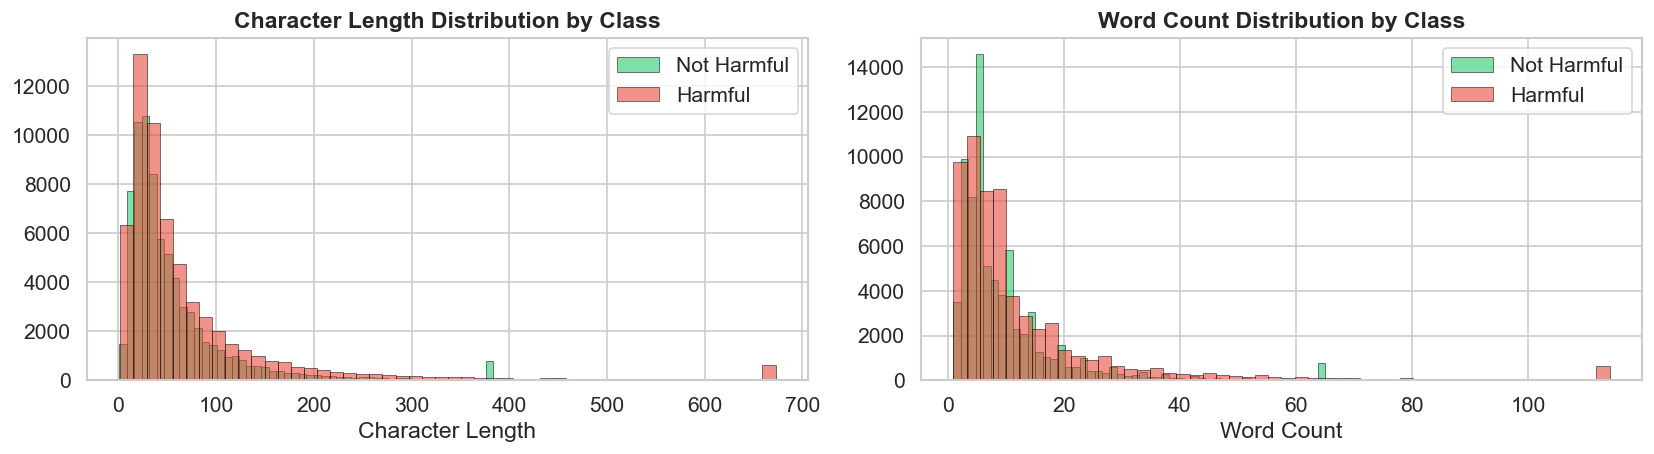

In [10]:
if "label_binary" in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    label_map = {0: "Not Harmful", 1: "Harmful"}
    colors_cls = {0: "#2ecc71", 1: "#e74c3c"}

    # Character length
    for lab, grp in df.groupby("label_binary"):
        axes[0].hist(grp["_char_len"].clip(upper=grp["_char_len"].quantile(0.99)),
                     bins=50, alpha=0.6, label=label_map.get(lab, str(lab)),
                     color=colors_cls.get(lab, "gray"),
                     edgecolor="black", linewidth=0.5)
    axes[0].set_title("Character Length Distribution by Class", fontweight="bold")
    axes[0].set_xlabel("Character Length")
    axes[0].legend()

    # Word count
    for lab, grp in df.groupby("label_binary"):
        axes[1].hist(grp["_word_count"].clip(upper=grp["_word_count"].quantile(0.99)),
                     bins=50, alpha=0.6, label=label_map.get(lab, str(lab)),
                     color=colors_cls.get(lab, "gray"),
                     edgecolor="black", linewidth=0.5)
    axes[1].set_title("Word Count Distribution by Class", fontweight="bold")
    axes[1].set_xlabel("Word Count")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig("../outputs/fig_length_by_class.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("⚠ 'label_binary' column not found — skipping.")

## 3 — Text Preprocessing Pipeline

We apply a **light** preprocessing pipeline as specified in the plan. Transformer models (BanglaBERT, MuRIL, XLM-R) have their own tokenizers, so heavy preprocessing can actually hurt performance. We focus on:

1. **Unicode normalization** — NFKC normalization for consistent Bangla rendering
2. **Emoji mapping** — convert emojis to text placeholders
3. **URL / mention masking** — replace URLs and @mentions with `[URL]` and `[USER]`
4. **Repeated character reduction** — collapse 3+ consecutive identical chars to 2
5. **Whitespace cleanup** — normalize spacing
6. **Bangla-specific cleanup** — remove zero-width joiners/non-joiners, normalize rendering

> **Design decision:** We do NOT stem, lowercase aggressively, or remove stopwords because transformer tokenizers handle subword segmentation natively. Overly aggressive cleaning can remove signal (e.g., ALL CAPS indicates shouting, repeated chars indicate emphasis).

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# PREPROCESSING FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════

def unicode_normalize(text):
    """NFKC normalization for consistent Bangla rendering."""
    return unicodedata.normalize("NFKC", text)


def mask_urls(text):
    """Replace URLs with [URL] token."""
    url_pattern = re.compile(
        r'https?://\S+|www\.\S+|[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}/\S*'
    )
    return url_pattern.sub("[URL]", text)


def mask_mentions(text):
    """Replace @mentions with [USER] token."""
    return re.compile(r'@[\w]+').sub("[USER]", text)


def mask_hashtags(text):
    """Replace hashtag symbol but keep the word: #topic -> [HASHTAG] topic."""
    return re.compile(r'#(\S+)').sub(r"[HASHTAG] \1", text)


def map_emojis(text):
    """Replace common emojis with text descriptors."""
    try:
        import emoji
        return emoji.demojize(text, delimiters=(" [EMOJI_", "] "))
    except ImportError:
        # Fallback: remove emojis via regex (covers most emoji Unicode ranges)
        emoji_pattern = re.compile(
            "["
            "\U0001F600-\U0001F64F"  # emoticons
            "\U0001F300-\U0001F5FF"  # symbols & pictographs
            "\U0001F680-\U0001F6FF"  # transport & map
            "\U0001F1E0-\U0001F1FF"  # flags
            "\U00002702-\U000027B0"
            "\U000024C2-\U0001F251"
            "]+", flags=re.UNICODE
        )
        return emoji_pattern.sub("[EMOJI]", text)


def reduce_repeated_chars(text, max_repeat=2):
    """Collapse 3+ consecutive identical characters to max_repeat.
    Example: 'হাাাা' -> 'হাা'  but 'হাহাহা' stays (different chars alternating)
    """
    pattern = re.compile(r'(.)\1{' + str(max_repeat) + r',}')
    return pattern.sub(r'\1' * max_repeat, text)


def clean_bangla_special(text):
    """Remove zero-width characters and normalize Bangla-specific issues."""
    text = text.replace("\u200c", "")  # ZWNJ
    text = text.replace("\u200d", "")  # ZWJ
    text = text.replace("\u200b", "")  # ZWSP
    text = text.replace("\ufeff", "")  # BOM
    return text


def normalize_whitespace(text):
    """Collapse multiple spaces/newlines into single space."""
    text = re.sub(r'[\n\r\t]+', ' ', text)
    text = re.sub(r' {2,}', ' ', text)
    return text.strip()


def preprocess_text(text):
    """Full preprocessing pipeline."""
    if not isinstance(text, str) or not text.strip():
        return ""
    
    text = unicode_normalize(text)
    text = clean_bangla_special(text)
    text = mask_urls(text)
    text = mask_mentions(text)
    text = mask_hashtags(text)
    text = map_emojis(text)
    text = reduce_repeated_chars(text)
    text = normalize_whitespace(text)
    
    return text


# ── Quick test ──────────────────────────────────────────────────────────────
test_cases = [
    "এটা একটা টেস্ট @user123 https://example.com 😂😂😂",
    "তুই একটা #বোকা খুব খারাপপপপপ",
    "tor matha kharap naki???? 🤬🤬",
    "  extra   spaces   and\n\nnewlines  ",
    "আমি তোকে মারবো\u200b\u200c\u200d শালা",
]

print("── Preprocessing examples ──\n")
for t in test_cases:
    print(f"  IN:  {repr(t)}")
    print(f"  OUT: {repr(preprocess_text(t))}")
    print()

── Preprocessing examples ──

  IN:  'এটা একটা টেস্ট @user123 https://example.com 😂😂😂'
  OUT: 'এটা একটা টেস্ট [USER] [URL] [EMOJI]'

  IN:  'তুই একটা #বোকা খুব খারাপপপপপ'
  OUT: 'তুই একটা [HASHTAG] বোকা খুব খারাপপ'

  IN:  'tor matha kharap naki???? 🤬🤬'
  OUT: 'tor matha kharap naki?? 🤬🤬'

  IN:  '  extra   spaces   and\n\nnewlines  '
  OUT: 'extra spaces and newlines'

  IN:  'আমি তোকে মারবো\u200b\u200c\u200d শালা'
  OUT: 'আমি তোকে মারবো শালা'



### 3.1 — Apply Preprocessing to Full Dataset

In [12]:
print("Applying preprocessing pipeline...")
df["text_clean"] = df["text"].apply(preprocess_text)

# Drop empty texts after cleaning
n_before = len(df)
df = df[df["text_clean"].str.len() > 0].reset_index(drop=True)
n_after = len(df)
print(f"Removed {n_before - n_after} empty texts after cleaning.")
print(f"Dataset size: {n_before:,} → {n_after:,}")

# Update length columns
df["_char_len_clean"] = df["text_clean"].str.len()
df["_word_count_clean"] = df["text_clean"].str.split().str.len()

print(f"\n── Cleaned text length (chars) ──")
print(df["_char_len_clean"].describe().round(1))

Applying preprocessing pipeline...
Removed 0 empty texts after cleaning.
Dataset size: 135,575 → 135,575

── Cleaned text length (chars) ──
count    135575.0
mean         69.5
std          99.4
min           1.0
25%          24.0
50%          40.0
75%          75.0
max        1953.0
Name: _char_len_clean, dtype: float64


### 3.2 — Before vs After Cleaning: Length Comparison

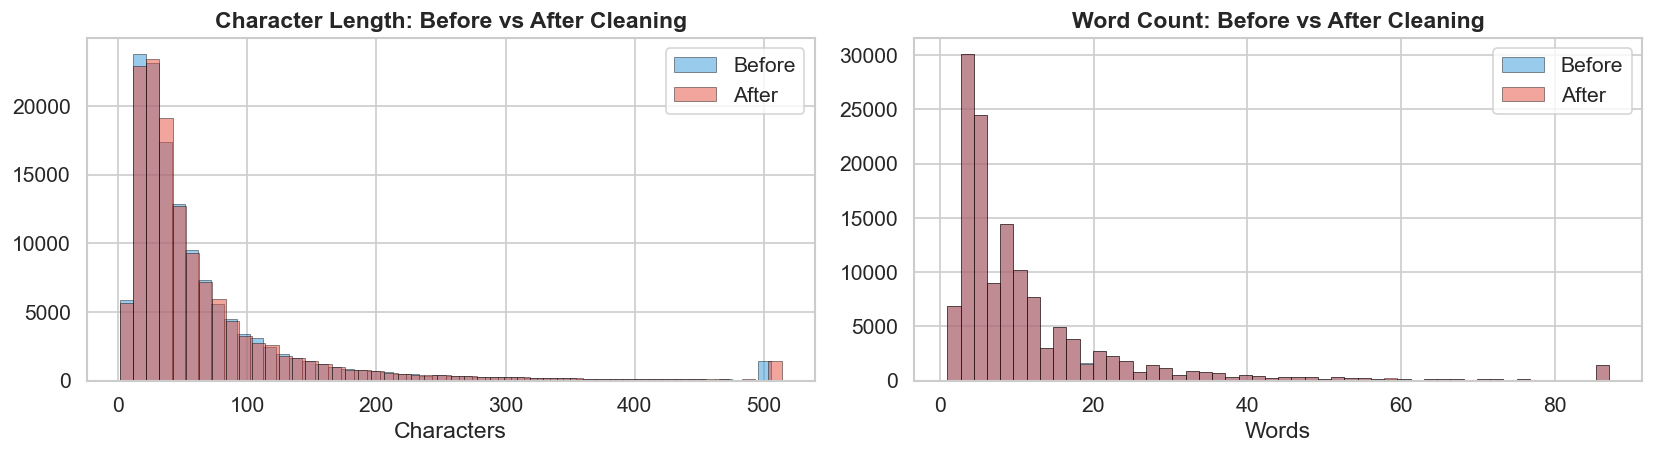

── Character reduction stats ──
  Mean reduction  : -0.4 chars
  Median reduction: 0.0 chars
  Max reduction   : 1612 chars


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df["_char_len"].clip(upper=df["_char_len"].quantile(0.99)),
             bins=50, alpha=0.5, label="Before", color="#3498db", edgecolor="black", linewidth=0.5)
axes[0].hist(df["_char_len_clean"].clip(upper=df["_char_len_clean"].quantile(0.99)),
             bins=50, alpha=0.5, label="After", color="#e74c3c", edgecolor="black", linewidth=0.5)
axes[0].set_title("Character Length: Before vs After Cleaning", fontweight="bold")
axes[0].set_xlabel("Characters")
axes[0].legend()

axes[1].hist(df["_word_count"].clip(upper=df["_word_count"].quantile(0.99)),
             bins=50, alpha=0.5, label="Before", color="#3498db", edgecolor="black", linewidth=0.5)
axes[1].hist(df["_word_count_clean"].clip(upper=df["_word_count_clean"].quantile(0.99)),
             bins=50, alpha=0.5, label="After", color="#e74c3c", edgecolor="black", linewidth=0.5)
axes[1].set_title("Word Count: Before vs After Cleaning", fontweight="bold")
axes[1].set_xlabel("Words")
axes[1].legend()

plt.tight_layout()
plt.savefig("../outputs/fig_length_before_after.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary
len_diff = (df["_char_len"] - df["_char_len_clean"])
print("── Character reduction stats ──")
print(f"  Mean reduction  : {len_diff.mean():.1f} chars")
print(f"  Median reduction: {len_diff.median():.1f} chars")
print(f"  Max reduction   : {len_diff.max():.0f} chars")

### 3.3 — Duplicate Analysis (Post-Cleaning)

In [14]:
n_dup = df["text_clean"].duplicated().sum()
print(f"Duplicate texts after cleaning: {n_dup:,} ({n_dup/len(df)*100:.1f}%)")

if n_dup > 0:
    # Show a few examples of duplicates
    dup_texts = df[df["text_clean"].duplicated(keep=False)].sort_values("text_clean")
    print(f"\nTop duplicated texts:")
    for t, cnt in dup_texts["text_clean"].value_counts().head(5).items():
        print(f"  [{cnt}x] {t[:80]}{'...' if len(t) > 80 else ''}")

    # Remove duplicates — keep first occurrence
    df_dedup = df.drop_duplicates(subset="text_clean", keep="first").reset_index(drop=True)
    print(f"\nAfter dedup: {len(df):,} → {len(df_dedup):,}")

    # ⚠ We keep BOTH versions — the user can decide which to use downstream
    # Uncomment the next line to use deduplicated version:
    # df = df_dedup
    print("\n⚠ Deduplication NOT applied by default. Uncomment `df = df_dedup` above if desired.")
else:
    print("No duplicates found — dataset is clean.")

Duplicate texts after cleaning: 41,238 (30.4%)

Top duplicated texts:
  [37x] নাউজুবিল্লাহ
  [33x] নাইচ
  [27x] মাগি
  [24x] নাইস
  [24x] সেই

After dedup: 135,575 → 94,337

⚠ Deduplication NOT applied by default. Uncomment `df = df_dedup` above if desired.


### 3.4 — Most Common Words / Tokens

In [15]:
def get_top_tokens(series, n=20):
    """Get top-n most frequent tokens from a text series."""
    all_tokens = []
    for text in series.dropna():
        all_tokens.extend(str(text).split())
    return Counter(all_tokens).most_common(n)

# Overall
print("── Top 20 tokens (all data) ──")
for tok, cnt in get_top_tokens(df["text_clean"], 20):
    print(f"  {cnt:>6,}  {tok}")

# Per class (if binary labels exist)
if "label_binary" in df.columns:
    print("\n── Top 15 tokens (Harmful class) ──")
    harmful = df[df["label_binary"] == 1]["text_clean"]
    for tok, cnt in get_top_tokens(harmful, 15):
        print(f"  {cnt:>6,}  {tok}")

    print("\n── Top 15 tokens (Not Harmful class) ──")
    not_harmful = df[df["label_binary"] == 0]["text_clean"]
    for tok, cnt in get_top_tokens(not_harmful, 15):
        print(f"  {cnt:>6,}  {tok}")

── Top 20 tokens (all data) ──
  11,708  না
   8,798  করে
   8,698  na
   8,007  কি
   6,810  এই
   6,577  [EMOJI]
   6,456  er
   6,448  আর
   5,950  ki
   5,268  বিশ্বাস
   5,132  তো
   4,721  আমি
   4,715  নাস্তিক
   4,574  আল্লাহ
   4,537  kore
   4,522  কে
   4,412  যে
   4,405  তুই
   4,343  কথা
   4,204  ও

── Top 15 tokens (Harmful class) ──
   9,096  না
   6,577  করে
   6,227  কি
   5,138  এই
   4,942  আর
   4,781  বিশ্বাস
   4,699  নাস্তিক
   4,250  তুই
   4,217  তো
   3,518  যে
   3,396  তোর
   3,276  কে
   3,109  কথা
   3,095  আমি
   3,060  একটা

── Top 15 tokens (Not Harmful class) ──
   6,736  na
   5,006  [EMOJI]
   4,686  er
   4,602  ki
   3,451  kore
   3,036  k
   2,912  r
   2,612  না
   2,579  to
   2,551  e
   2,456  kotha
   2,432  police
   2,398  ar
   2,397  hobe
   2,347  ke


### 3.5 — Cross-tabulation Tables (for Paper)

In [16]:
os.makedirs("../outputs", exist_ok=True)

if "source" in df.columns and "label_binary" in df.columns:
    ct = pd.crosstab(df["source"], df["label_binary"], margins=True)
    ct.columns = ["Not Harmful", "Harmful", "Total"]
    ct.index.name = "Source"
    print("── Source × Binary Label ──")
    print(ct.to_string())
    ct.to_csv("../outputs/table_source_by_label.csv")
    print("\n→ Saved: ../outputs/table_source_by_label.csv")

if "source" in df.columns and "label_type" in df.columns:
    ct2 = pd.crosstab(df["source"], df["label_type"], margins=True)
    ct2.index.name = "Source"
    print("\n── Source × Abuse Type ──")
    print(ct2.to_string())
    ct2.to_csv("../outputs/table_source_by_type.csv")
    print("\n→ Saved: ../outputs/table_source_by_type.csv")

── Source × Binary Label ──
                  Not Harmful  Harmful   Total
Source                                        
banth                   53098    20901   73999
bd_shs                   2613     2416    5029
facebook_44001          15340    28661   44001
multilabel_12557         4494     8052   12546
All                     75545    60030  135575

→ Saved: ../outputs/table_source_by_label.csv

── Source × Abuse Type ──
label_type        Abusive/Violence  Abusive/Violence,Body Shaming  Abusive/Violence,Misc  Abusive/Violence,Origin  Body Shaming  Gender  Gender,Abusive/Violence  Gender,Body Shaming  Gender,Misc  Gender,Origin  Gender,Personal Offense  Gender,Personal Offense,Abusive/Violence  Gender,Personal Offense,Abusive/Violence,Body Shaming  Gender,Personal Offense,Abusive/Violence,Origin  Gender,Personal Offense,Body Shaming  Gender,Personal Offense,Origin  Misc  Origin  Origin,Body Shaming  Origin,Misc  Personal Offense  Personal Offense,Abusive/Violence  Personal Offense

## 4 — Save Preprocessed Dataset

In [17]:
# ── Drop temp columns ──────────────────────────────────────────────────────
cols_to_drop = [c for c in df.columns if c.startswith("_")]
df_save = df.drop(columns=cols_to_drop)

# ── Save ────────────────────────────────────────────────────────────────────
os.makedirs("../data/processed", exist_ok=True)

out_path = "../data/processed/benchmark_cleaned.csv"
df_save.to_csv(out_path, index=False, encoding="utf-8-sig")
print(f"✅ Saved preprocessed data → {out_path}")
print(f"   Shape: {df_save.shape}")
print(f"   Columns: {list(df_save.columns)}")

# Also save a small sample for quick inspection
sample_path = "../data/processed/benchmark_cleaned_sample.csv"
df_save.sample(min(100, len(df_save)), random_state=42).to_csv(
    sample_path, index=False, encoding="utf-8-sig"
)
print(f"   Sample (100 rows) → {sample_path}")

✅ Saved preprocessed data → ../data/processed/benchmark_cleaned.csv
   Shape: (135575, 7)
   Columns: ['text', 'label_binary', 'label_type', 'source', 'script', 'original_file', 'text_clean']
   Sample (100 rows) → ../data/processed/benchmark_cleaned_sample.csv


## 5 — Summary Statistics for Paper

These statistics are useful for the dataset description section of the paper.

In [18]:
print("=" * 60)
print("BENCHMARK DATASET SUMMARY (for paper)")
print("=" * 60)
print(f"Total samples        : {len(df_save):,}")
if "source" in df_save.columns:
    print(f"Number of sources    : {df_save['source'].nunique()}")
    print(f"  Sources            : {sorted(df_save['source'].unique())}")
if "label_binary" in df_save.columns:
    vc = df_save["label_binary"].value_counts()
    print(f"Harmful samples      : {vc.get(1, 0):,} ({vc.get(1, 0)/len(df_save)*100:.1f}%)")
    print(f"Not harmful samples  : {vc.get(0, 0):,} ({vc.get(0, 0)/len(df_save)*100:.1f}%)")
if "label_type" in df_save.columns:
    # Convert to string and drop nulls to avoid TypeError
    label_types_clean = df_save['label_type'].dropna().astype(str)
    print(f"Abuse type classes   : {label_types_clean.nunique()}")
    # Sort after converting to string
    print(f"  Categories         : {sorted(label_types_clean.unique())}")
if "label_severity" in df_save.columns:
    severity_clean = df_save['label_severity'].dropna().astype(str)
    print(f"Severity classes     : {severity_clean.nunique()}")
    print(f"  Levels             : {sorted(severity_clean.unique())}")
if "script" in df_save.columns:
    print(f"Script types         : {dict(df_save['script'].value_counts())}")
print(f"Avg text length      : {df_save['text_clean'].str.len().mean():.0f} chars")
print(f"Median text length   : {df_save['text_clean'].str.len().median():.0f} chars")
print(f"Max text length      : {df_save['text_clean'].str.len().max():,} chars")
print(f"Avg word count       : {df_save['text_clean'].str.split().str.len().mean():.1f}")
print("=" * 60)

BENCHMARK DATASET SUMMARY (for paper)
Total samples        : 135,575
Number of sources    : 4
  Sources            : ['banth', 'bd_shs', 'facebook_44001', 'multilabel_12557']
Harmful samples      : 60,030 (44.3%)
Not harmful samples  : 75,545 (55.7%)
Abuse type classes   : 89
  Categories         : ['Abusive/Violence', 'Abusive/Violence,Body Shaming', 'Abusive/Violence,Misc', 'Abusive/Violence,Origin', 'Body Shaming', 'Gender', 'Gender,Abusive/Violence', 'Gender,Body Shaming', 'Gender,Misc', 'Gender,Origin', 'Gender,Personal Offense', 'Gender,Personal Offense,Abusive/Violence', 'Gender,Personal Offense,Abusive/Violence,Body Shaming', 'Gender,Personal Offense,Abusive/Violence,Origin', 'Gender,Personal Offense,Body Shaming', 'Gender,Personal Offense,Origin', 'Misc', 'Origin', 'Origin,Body Shaming', 'Origin,Misc', 'Personal Offense', 'Personal Offense,Abusive/Violence', 'Personal Offense,Abusive/Violence,Body Shaming', 'Personal Offense,Abusive/Violence,Misc', 'Personal Offense,Body Shami

---
**Next:** Notebook `03_data_splits.ipynb` — Create train/val/test splits:
- Random split (80/10/10)
- Source-held-out split
- Script-held-out split (Romanized held out)
- External-test setup